In [1]:
import numpy as np
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical

(train_images, train_labels), (test_images, test_labels) = datasets.mnist.load_data()

train_images = train_images / 255.0
test_images = test_images / 255.0

train_images = train_images.reshape(train_images.shape[0], 28, 28, 1)
test_images = test_images.reshape(test_images.shape[0], 28, 28, 1)

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

In [2]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))

model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

model.add(layers.Conv2D(64, (3, 3), activation='relu'))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

C:\Users\ShwetaAmale\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [3]:
model.compile(optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy'])

In [4]:
model.fit(train_images, train_labels, epochs=5, batch_size=64, validation_data=(test_images, test_labels))

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 33s 31ms/step - accuracy: 0.9397 - loss: 0.1905 - val_accuracy: 0.9750 - val_loss: 0.0768
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 29s 31ms/step - accuracy: 0.9838 - loss: 0.0528 - val_accuracy: 0.9860 - val_loss: 0.0407
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 26s 28ms/step - accuracy: 0.9885 - loss: 0.0375 - val_accuracy: 0.9864 - val_loss: 0.0408
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.9911 - loss: 0.0292 - val_accuracy: 0.9869 - val_loss: 0.0384
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 30s 32ms/step - accuracy: 0.9923 - loss: 0.0233 - val_accuracy: 0.9918 - val_loss: 0.0265


In [5]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9918 - loss: 0.0265


In [6]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9918 - loss: 0.0265


In [7]:
predictions = model.predict(test_images)
print(f"Prediction for first test image: {np.argmax(predictions[0])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Prediction for first test image: 7


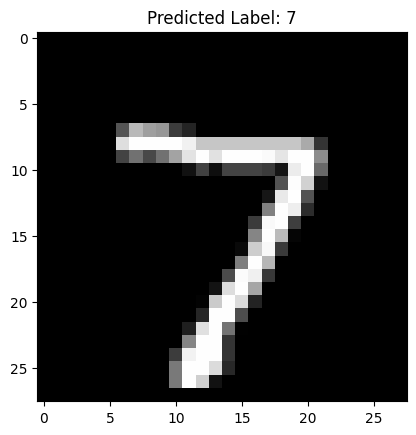

In [8]:
import matplotlib.pyplot as plt

plt.imshow(test_images[0].reshape(28, 28), cmap='gray')
plt.title(f"Predicted Label: {predictions[0].argmax()}")
plt.show()

In [20]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

train_dir = 'C:\\Users\\ShwetaAmale\\OneDrive - Packt\\Desktop\\B39388 Code Testing\\training_set\\training_set'
validation_dir = 'C:\\Users\\ShwetaAmale\\OneDrive - Packt\\Desktop\\B39388 Code Testing\\test_set'

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [21]:
validation_datagen = ImageDataGenerator(rescale=1./255)

In [22]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 8005 images belonging to 2 classes.
Found 2023 images belonging to 1 classes.


In [23]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)))
model.add(layers.MaxPooling2D((2, 2)))

In [24]:
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

In [25]:
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

In [26]:
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

In [27]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [28]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 34, 34, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 17, 17, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 36992)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │      18,940,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │             513 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,034,177 (72.61 MB)

 Trainable params: 19,034,177 (72.61 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator
)

Epoch 1/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 535s 2s/step - accuracy: 0.5157 - loss: 0.7179 - val_accuracy: 0.3604 - val_loss: 0.6791
Epoch 2/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 132s 525ms/step - accuracy: 0.5588 - loss: 0.6844 - val_accuracy: 0.5245 - val_loss: 0.6500
Epoch 3/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 128s 511ms/step - accuracy: 0.5854 - loss: 0.6743 - val_accuracy: 0.5581 - val_loss: 0.6994
Epoch 4/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 127s 504ms/step - accuracy: 0.6436 - loss: 0.6330 - val_accuracy: 0.4617 - val_loss: 0.8744
Epoch 5/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 286s 1s/step - accuracy: 0.6854 - loss: 0.5958 - val_accuracy: 0.4325 - val_loss: 1.0296
Epoch 6/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 160s 639ms/step - accuracy: 0.6887 - loss: 0.5819 - val_accuracy: 0.3989 - val_loss: 1.3097
Epoch 7/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 142s 564ms/step - accuracy: 0.6988 - loss: 0.5695 - val_accuracy: 0.5284 - val_loss: 1.0950
Epoch 8/20
251/251 ━━━━━━━━━━━━━━━━━━━━ 157s 626ms/step - accuracy: 0.7128 - loss:

In [30]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(len(acc))

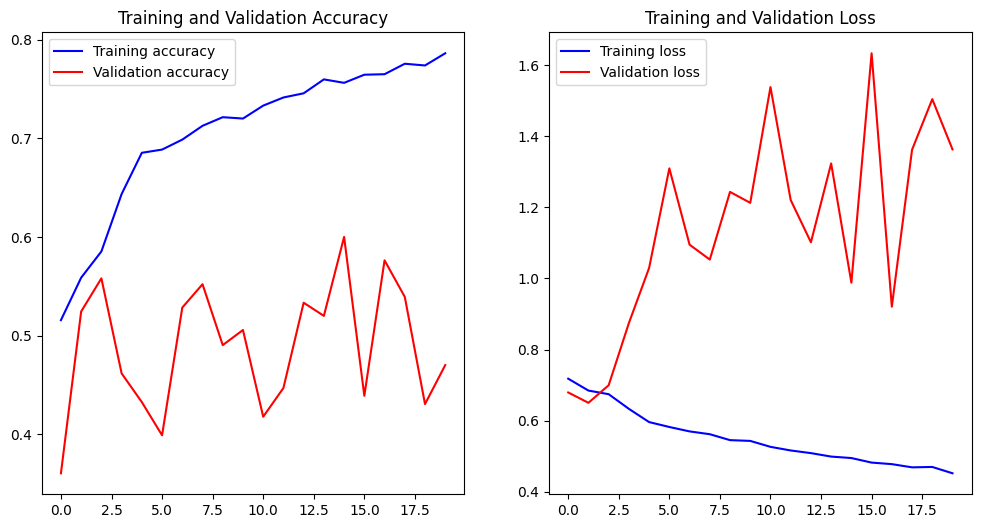

In [31]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b', label='Training accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.show()

In [32]:
from tensorflow.keras.preprocessing import image
import numpy as np

def predict_image(model, image_path):
    img = image.load_img(image_path, target_size=(150, 150))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0
    prediction = model.predict(img_array)

    if prediction[0][0] > 0.5:
        print(f"The image is predicted to be a dog with confidence {prediction[0][0]:.2f}")
    else:
        print(f"The image is predicted to be a cat with confidence {1 - prediction[0][0]:.2f}")

In [37]:
predict_image(model, 'C:\\Users\\ShwetaAmale\\OneDrive - Packt\\Desktop\\B39388 Code Testing\\test_image.jpg')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
The image is predicted to be a cat with confidence 1.00


In [38]:
import numpy as np

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

def mean_squared_error(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

In [46]:
class BasicNeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.weights_input_hidden = np.random.randn(input_size, hidden_size)
        self.weights_hidden_output = np.random.randn(hidden_size, output_size)

        self.bias_hidden = np.random.randn(1, hidden_size)
        self.bias_output = np.random.randn(1, output_size)

    def forward(self, X):
        self.hidden_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
        self.hidden_output = sigmoid(self.hidden_input)

        self.output_input = np.dot(
            self.hidden_output,
            self.weights_hidden_output
        ) + self.bias_output

        self.output = sigmoid(self.output_input)

        return self.output

    def backward(self, X, y, output, learning_rate):
        output_error = y - output
        output_delta = output_error * sigmoid_derivative(output)

        hidden_error = np.dot(
            output_delta,
            self.weights_hidden_output.T
        )

        hidden_delta = hidden_error * sigmoid_derivative(self.hidden_output)

        # Update weights
        self.weights_hidden_output += (
            np.dot(self.hidden_output.T, output_delta)
            * learning_rate
        )

        self.weights_input_hidden += (
            np.dot(X.T, hidden_delta)
            * learning_rate
        )

        # Update biases
        self.bias_output += (
            np.sum(output_delta, axis=0, keepdims=True)
            * learning_rate
        )

        self.bias_hidden += (
            np.sum(hidden_delta, axis=0, keepdims=True)
            * learning_rate
        )

    def train(self, x, y, epochs, learning_rate):
        for epoch in range(epochs):

            # Forward pass
            output = self.forward(x)

            # Backward pass
            self.backward(x, y, output, learning_rate)

            # Print loss every 100 epochs
            if epoch % 100 == 0:
                loss = np.mean(np.square(y - output))
                print(f"Epoch: {epoch}, Loss: {loss}")

In [47]:
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

Y = np.array([[0], [1], [1], [0]])

nn = BasicNeuralNetwork(input_size=2, hidden_size=2, output_size=1)

nn.train(X, Y, epochs=10000, learning_rate=0.1)

print("\nTesting the trained neural network.")
for i in range(len(X)):
    print(f"Input: {X[i]}, Predicted Output: {nn.forward(X[i])}, Actual Output: {Y[i]}")

Epoch: 0, Loss: 0.2976529367957344
Epoch: 100, Loss: 0.24343587782579743
Epoch: 200, Loss: 0.24128986097616628
Epoch: 300, Loss: 0.2386855061461679
Epoch: 400, Loss: 0.23541460704015968
Epoch: 500, Loss: 0.23131606916898434
Epoch: 600, Loss: 0.22622657617459938
Epoch: 700, Loss: 0.21997116341672693
Epoch: 800, Loss: 0.21233509515999935
Epoch: 900, Loss: 0.20302430710318292
Epoch: 1000, Loss: 0.19164731368057847
Epoch: 1100, Loss: 0.1777773420898617
Epoch: 1200, Loss: 0.16118949768199453
Epoch: 1300, Loss: 0.14228379120712553
Epoch: 1400, Loss: 0.12232484062782094
Epoch: 1500, Loss: 0.10304011280202519
Epoch: 1600, Loss: 0.08584202355725634
Epoch: 1700, Loss: 0.07138635425784731
Epoch: 1800, Loss: 0.059666376950212416
Epoch: 1900, Loss: 0.050326076624839775
Epoch: 2000, Loss: 0.04291318950109833
Epoch: 2100, Loss: 0.037007823909359555
Epoch: 2200, Loss: 0.032265124979319784
Epoch: 2300, Loss: 0.028417201806688278
Epoch: 2400, Loss: 0.025260968674490153
Epoch: 2500, Loss: 0.0226437165836

In [48]:
import nltk
from nltk.corpus import movie_reviews
from nltk.classify import NaiveBayesClassifier
from nltk.classify.util import accuracy as nltk_accuracy
from nltk.corpus import stopwords
import random
nltk.download('movie_reviews')
nltk.download('punkt')
nltk.download('stopwords')
def extract_features(words):
    return {word: True for word in words}

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\ShwetaAmale\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ShwetaAmale\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ShwetaAmale\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [49]:
documents = [(list(movie_reviews.words(fileid)), category)
            for category in movie_reviews.categories()
            for fileid in movie_reviews.fileids(category)]

In [50]:
random.shuffle(documents)

In [51]:
feature_sets = [(extract_features(d), c) for (d, c) in documents]

train_set, test_set = feature_sets[:1600], feature_sets[1600:]

classifier = nltk.NaiveBayesClassifier.train(train_set)

accuracy = nltk.classify.accuracy(classifier, test_set)
print(f"Accuracy: {accuracy * 100:.2f}%")

classifier.show_most_informative_features(10)

Accuracy: 68.50%
Most Informative Features
                poignant = True              pos : neg    =     14.2 : 1.0
             outstanding = True              pos : neg    =     13.1 : 1.0
              astounding = True              pos : neg    =     10.9 : 1.0
             fascination = True              pos : neg    =     10.2 : 1.0
             magnificent = True              pos : neg    =      9.7 : 1.0
                  avoids = True              pos : neg    =      9.5 : 1.0
                   warns = True              pos : neg    =      9.5 : 1.0
                   sucks = True              neg : pos    =      9.5 : 1.0
                   damon = True              pos : neg    =      9.3 : 1.0
               marvelous = True              pos : neg    =      9.3 : 1.0


In [52]:
def analyze_sentiment(text):
    words = nltk.word_tokenize(text)
    words = [word.lower() for word in words if word.lower() not in stopwords.words('english')]

    features = extract_features(words)
    return classifier.classify(features)


In [53]:
test_sentences = [
    "This movie is absolutely fantastic, the acting, the story, everything was amazing.",
    "I hated this movie just from the start.",
    "The plot was a bit dull, but the performance was great, which means I have a very neutral type, but end of the day, I like the movie.",
    "I have mixed feelings about the film. It was OK, not great."
]

for sentence in test_sentences:
    print(f"Sentence: {sentence}")
    print(f"Predicted sentiment is: {analyze_sentiment(sentence)}")
    print()


Sentence: This movie is absolutely fantastic, the acting, the story, everything was amazing.
Predicted sentiment is: pos

Sentence: I hated this movie just from the start.
Predicted sentiment is: neg

Sentence: The plot was a bit dull, but the performance was great, which means I have a very neutral type, but end of the day, I like the movie.
Predicted sentiment is: pos

Sentence: I have mixed feelings about the film. It was OK, not great.
Predicted sentiment is: pos



In [54]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ShwetaAmale\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ShwetaAmale\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [55]:
text = """
Artificial intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think like humans and mimic their actions. The term may also be applied to any machine that exhibits traits associated with the human mind, such as learning and problem-solving. 

The ideal characteristic of artificial intelligence is its ability to rationalize and take actions that have the best chance of achieving a specific goal. A subset of artificial intelligence is machine learning, which refers to the concept that computer programs can automatically learn from and adapt to new data without being assisted by humans. 
Deep learning techniques enable this automatic learning through the absorption of huge amounts of unstructured data such as text, images, or video.
"""


In [56]:
def summarize_text(text, num_sentences=2):
    # Tokenize the text into sentences
    sentences = sent_tokenize(text)

    # Tokenize the text into words and convert to lowercase
    words = word_tokenize(text.lower())
    
    # Set of English stopwords
    stop_words = set(stopwords.words("english"))

    # Calculate word frequencies, ignoring stopwords and non-alphabetic words
    word_frequencies = {}
    for word in words:
        if word.isalpha() and word not in stop_words:
            word_frequencies[word] = word_frequencies.get(word, 0) + 1
            # Score each sentence based on word frequencies
            sentence_scores = {}
            for sentence in sentences:
                for word in word_tokenize(sentence.lower()):
                    if word in word_frequencies:
                        sentence_scores[sentence] = sentence_scores.get(sentence, 0) + word_frequencies[word]
                        # Sort sentences by score and select the top num_sentences
                        summary_sentences = sorted(sentence_scores, key=sentence_scores.get, reverse=True)[:num_sentences]
                        # Join the selected sentences to form the summary
                        summary = " ".join(summary_sentences)
                        return summary


In [57]:
summary = summarize_text(text, num_sentences=2)
print("Original Text:\n", text)
print("\nSummary:\n", summary)

Original Text:
 
Artificial intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think like humans and mimic their actions. The term may also be applied to any machine that exhibits traits associated with the human mind, such as learning and problem-solving. 

The ideal characteristic of artificial intelligence is its ability to rationalize and take actions that have the best chance of achieving a specific goal. A subset of artificial intelligence is machine learning, which refers to the concept that computer programs can automatically learn from and adapt to new data without being assisted by humans. 
Deep learning techniques enable this automatic learning through the absorption of huge amounts of unstructured data such as text, images, or video.


Summary:
 
Artificial intelligence (AI) refers to the simulation of human intelligence in machines that are programmed to think like humans and mimic their actions.


In [58]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [61]:
df = pd.read_csv('fake reviews dataset.csv')
df = df.rename(columns={'text_': 'review_text'})
df['label'] = df['label'].replace({'CG': 'fake', 'OR': 'genuine'})
print(df.head())

             category  rating label  \
0  Home_and_Kitchen_5     5.0  fake   
1  Home_and_Kitchen_5     5.0  fake   
2  Home_and_Kitchen_5     5.0  fake   
3  Home_and_Kitchen_5     1.0  fake   
4  Home_and_Kitchen_5     5.0  fake   

                                               text_  
0  Love this!  Well made, sturdy, and very comfor...  
1  love it, a great upgrade from the original.  I...  
2  This pillow saved my back. I love the look and...  
3  Missing information on how to use it, but it i...  
4  Very nice set. Good quality. We have had the s...  


In [63]:
X = df['review_text']
y = df['label']

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [66]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

In [67]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [68]:
X_test_tfidf = vectorizer.transform(X_test)

In [69]:
model = LogisticRegression(max_iter=1000, random_state=42)

In [70]:
model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [71]:
y_pred = model.predict(X_test_tfidf)

In [72]:
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.8659577099047855


In [73]:
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
print(f"\nAccuracy: {accuracy:.3f}")
print(f"\nClassification Report:\n{report}")


Accuracy: 0.866

Classification Report:
              precision    recall  f1-score   support

        fake       0.88      0.85      0.86      4044
     genuine       0.85      0.88      0.87      4043

    accuracy                           0.87      8087
   macro avg       0.87      0.87      0.87      8087
weighted avg       0.87      0.87      0.87      8087



In [74]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist

In [75]:
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\ShwetaAmale\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ShwetaAmale\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ShwetaAmale\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [76]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

In [77]:
text = """
I am so happy today. The weather is beautiful and everything is going well. I feel very positive and motivated.
"""

In [78]:
def detect_emotion(text):
    # Analyze the sentiment of the text
    scores = sid.polarity_scores(text)
    print(scores)  # Print the sentiment scores for inspection

    # Determine emotion based on the compound score
    if scores['compound'] >= 0.5:
        emotion = 'Joy'
    elif scores['compound'] <= -0.5:
        emotion = 'Sadness'
    elif scores['compound'] < 0:
        emotion = 'Anger'
    elif scores['compound'] == 0:
        emotion = 'Neutral'
    else:
        emotion = 'Mixed emotion'
    return emotion

In [79]:
emotion = detect_emotion(text)
print("Detected Emotion: ", emotion)

{'neg': 0.0, 'neu': 0.431, 'pos': 0.569, 'compound': 0.9528}
Detected Emotion:  Joy


In [80]:
import spacy
from spacy import displacy
import pandas as pd

nlp = spacy.load("en_core_web_sm")

In [81]:
text = """
Amazon announced its quarterly earnings on July 30, 2023.
As a CEO, Andy Jassy said the company is investing $4 billion in AI technology.
Google, based in Mountain View, California, also shared its financial report.
The 2024 Summer Olympics will be held in Paris, France.
"""
doc = nlp(text)
def extract_entities(doc):
    # Function body will be defined to extract named entities from doc
    pass

In [82]:
def extract_entities(doc):
    entities = []
    for ent in doc.ents:
        entities.append({
            "Entity": ent.text,
            "Label": ent.label_,
            "Explanation": spacy.explain(ent.label_)
            })
    return pd.DataFrame(entities)

entities_df = extract_entities(doc)

print("Extracted named entities:")
print(entities_df)

Extracted named entities:
           Entity   Label                                        Explanation
0          Amazon     ORG            Companies, agencies, institutions, etc.
1       quarterly    DATE              Absolute or relative dates or periods
2   July 30, 2023    DATE              Absolute or relative dates or periods
3      Andy Jassy  PERSON                        People, including fictional
4      $4 billion   MONEY                    Monetary values, including unit
5              AI     GPE                          Countries, cities, states
6          Google     ORG            Companies, agencies, institutions, etc.
7   Mountain View     GPE                          Countries, cities, states
8      California     GPE                          Countries, cities, states
9            2024    DATE              Absolute or relative dates or periods
10       Olympics   EVENT  Named hurricanes, battles, wars, sports events...
11          Paris     GPE                         

In [83]:
displacy.render(doc, style="ent", jupyter=True)

In [84]:
entities_df.to_csv("extracted_entities.csv", index=False)

In [85]:
print("\nEntities saved to ‘extracted_entities.csv'")


Entities saved to ‘extracted_entities.csv'


In [86]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score , classification_report

df = pd.read_csv('news_dataset.csv')

In [87]:
print("Dataset Sample:\n", df.head())

Dataset Sample:
                                                title  \
0   WATCH: Trump Just Told All The Anti-Gay Bigot...   
1  China backs U.N. call for justice in Yemen, U....   
2  THE PEOPLE’S PRESIDENT: Trump Meets With Coal ...   
3  WSJ REPORTER RIPS INTO DEM CANDIDATES For Thei...   
4  Lawmakers aim to delay U.S. ceding control of ...   

                                                text       subject  \
0  A whole lot of evangelical Trump voters just d...          News   
1  GENEVA (Reuters) - China signaled on Wednesday...     worldnews   
2                                                         politics   
3  THE WSJ S MARY KISSEL NAILS IT ON THE DEM DEBA...      politics   
4  WASHINGTON (Reuters) - Critics of a plan for t...  politicsNews   

                  date  label  
0    November 13, 2016      0  
1  September 13, 2017       1  
2         Feb 16, 2017      0  
3         Nov 15, 2015      0  
4  September 13, 2016       1  


In [88]:
X = df['title']
y = df['label']

In [89]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [90]:
vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [91]:
model = MultinomialNB()
model.fit(X_train_tfidf, y_train)
y_pred = model.predict(X_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, zero_division=0)
print(f"\nAccuracy: {accuracy:.3f}")
print(f"\nClassification Report:\n{report}")


Accuracy: 0.898

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90       600
           1       0.90      0.90      0.90       600

    accuracy                           0.90      1200
   macro avg       0.90      0.90      0.90      1200
weighted avg       0.90      0.90      0.90      1200



In [92]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [93]:
data = {
    'resume_id': [1, 2, 3],
    'resume_text': [
    'Experienced data scientist with skills in Python, machine learning, and data analysis.',
    'Software developer with expertise in Java, cloud computing, and project management.',
    'Data analyst with proficiency in SQL, Python, and data visualization.'
]
}

In [94]:
job_description = 'Looking for a data scientist skilled in Python, machine learning, SQL, and data analysis.'

In [95]:
df = pd.DataFrame(data)
print(df)

   resume_id                                        resume_text
0          1  Experienced data scientist with skills in Pyth...
1          2  Software developer with expertise in Java, clo...
2          3  Data analyst with proficiency in SQL, Python, ...


In [96]:
documents = df['resume_text'].to_list()
documents.append(job_description)
vectorizer = TfidfVectorizer(stop_words='english')
tfidf_matrix = vectorizer.fit_transform(documents)
similarity_scores = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1]).flatten()
df['similarity_score'] = similarity_scores
print("Resume similarity scores:")
print(df[['resume_id', 'similarity_score']])

Resume similarity scores:
   resume_id  similarity_score
0          1          0.662564
1          2          0.000000
2          3          0.418121


In [98]:
threshold = 0.2
matching_resumes = df[df.similarity_score >= threshold]
print("Resumes matching the job requirements:")
print(matching_resumes[['resume_id', 'similarity_score']])

Resumes matching the job requirements:
   resume_id  similarity_score
0          1          0.662564
2          3          0.418121


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel
from torch.optim import AdamW

In [3]:
import pandas as pd

df = pd.read_csv("ASAP2_train_sourcetexts.csv")

df.to_csv("essay_dataset.tsv", sep="\t", index=False)

In [4]:
df = pd.read_csv(
    'essay_dataset.tsv',
    sep='\t',
    encoding='ISO-8859-1'
)
df = df[['essay_id', 'score']]
df = df.rename(columns={'score': 'overall'}).dropna()
print(df.head())

               essay_id  overall
0  AAAVUP14319000159574        4
1  AAAVUP14319000159542        2
2  AAAVUP14319000159461        3
3  AAAVUP14319000159420        2
4  AAAVUP14319000159419        2


In [5]:
df = df[['essay_id', 'overall']].dropna()

In [6]:
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

In [7]:
class EssayDataset(Dataset):
    def __init__(self, essays, scores, tokenizer, max_length=512):
     self.essays = essays
     self.scores = scores
     self.tokenizer = tokenizer
     self.max_length = max_length

    def __len__(self):
        return len(self.essays)

    def __getitem__(self, index):
        essay = str(self.essays[index])
        score = self.scores[index]
       
        encoding = self.tokenizer.encode_plus(
        essay,
        add_special_tokens=True,
        max_length=self.max_length,
        padding='max_length',
        truncation=True,
        return_attention_mask=True,
        return_tensors='pt'
    )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'score': torch.tensor(score, dtype=torch.float)
    }

In [8]:
train_texts, val_texts, train_scores, val_scores = train_test_split(df['essay_id'], df['overall'], test_size=0.2, random_state=42)

In [9]:
train_dataset = EssayDataset(train_texts.tolist(), train_scores.tolist(), tokenizer)
val_dataset = EssayDataset(val_texts.tolist(), val_scores.tolist(), tokenizer)

In [10]:
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8)

In [11]:
class EssayGradingModel(torch.nn.Module):
    def __init__(self):
        super(EssayGradingModel, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        self.regressor = torch.nn.Linear(self.bert.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.pooler_output
        score = self.regressor(cls_output)
        return score.squeeze(-1)

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EssayGradingModel().to(device)
optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.MSELoss()

In [13]:
def train(model, data_loader, loss_fn, optimizer, device):
    model.train()
    total_loss = 0
    for batch in data_loader:
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        scores = batch['score'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs, scores)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(data_loader)

In [14]:
def evaluate(model, data_loader, loss_fn, device):
    model.eval()
    predictions = []
    true_scores = []
    total_loss = 0
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            scores = batch['score'].to(device)
            
            outputs = model(input_ids=input_ids,attention_mask=attention_mask)
            loss = loss_fn(outputs, scores)
            total_loss += loss.item()
            predictions.extend(outputs.detach().cpu().numpy().tolist())
            true_scores.extend(scores.detach().cpu().numpy().tolist())
    mse = mean_squared_error(true_scores, predictions)
    r2 = r2_score(true_scores, predictions)
    return total_loss / len(data_loader), mse, r2

In [ ]:
epochs = 3
for epoch in range(epochs):
    train_loss = train(model, train_loader, loss_fn, optimizer, device)
    val_loss, mse, r2 = evaluate(model, val_loader, loss_fn, device)
    print(f"Epoch {epoch + 1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, MSE: {mse:.4f}, R2: {r2:.4f}")

In [15]:
test_text = (
    "The essay provided insightful analysis of the topic with well-structured arguments."
)
encoding = tokenizer.encode_plus(
    test_text,
    add_special_tokens=True,
    max_length=512,
    padding='max_length',
    truncation=True,
    return_tensors='pt'
)

In [16]:
input_ids = encoding['input_ids'].to(device)

In [17]:
attention_mask = encoding['attention_mask'].to(device)

In [18]:
model.eval()

EssayGradingModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-

In [20]:
with torch.no_grad():
    predicted_score = model(input_ids, attention_mask=attention_mask).item()

In [21]:
print(f"Predicted score: {predicted_score:.2f}")

Predicted score: -0.28


In [22]:
losses = {
    'epoch': [1, 2, 3],
    'train_loss': [6.89, 0.75, 0.53],
    'val_loss': [0.69, 1.19, 0.91]
}

In [23]:
loss_df = pd.DataFrame(losses)

<Axes: xlabel='epoch', ylabel='train_loss'>

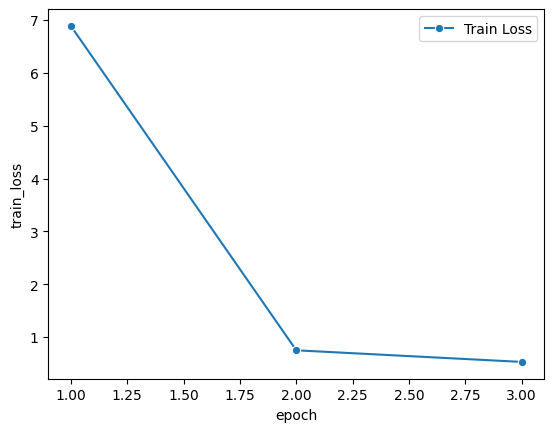

In [24]:
sns.lineplot(data=loss_df, x='epoch', y='train_loss', marker='o', label='Train Loss')

<Axes: xlabel='epoch', ylabel='val_loss'>

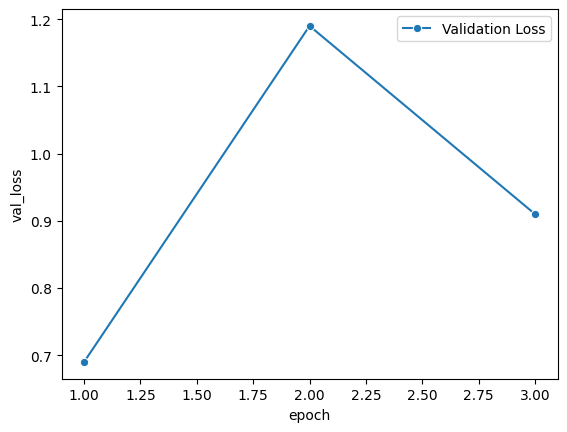

In [25]:
sns.lineplot(data=loss_df, x='epoch', y='val_loss', marker='o', label='Validation Loss')

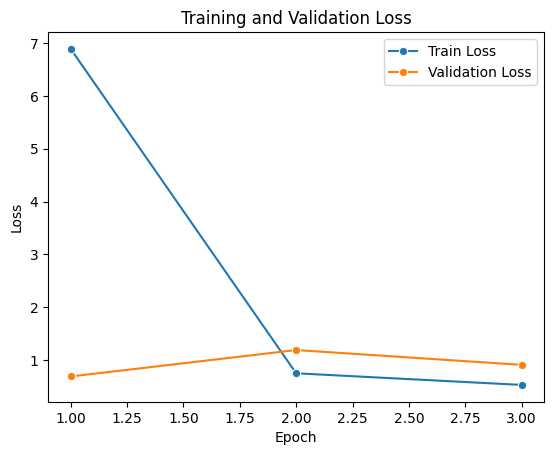

In [27]:
sns.lineplot(data=loss_df, x='epoch', y='train_loss', marker='o', label='Train Loss')
sns.lineplot(data=loss_df, x='epoch', y='val_loss', marker='o', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

In [28]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
movie_data = {
    'movie_id': [1, 2, 3, 4, 5],
    'title': ['The Matrix', 'John Wick', 'Godfather', 'Pulp Fiction', 'Dark Knight'],
    'genre': ['Action, Sci-Fi', 'Action , Thriller', 'Crime, Drama', 'Crime, Drama', 'Action, Crime, Drama']}

In [30]:
df = pd.DataFrame(movie_data)

In [31]:
print("Movie Data: ")
print(df)

Movie Data: 
   movie_id         title                 genre
0         1    The Matrix        Action, Sci-Fi
1         2     John Wick     Action , Thriller
2         3     Godfather          Crime, Drama
3         4  Pulp Fiction          Crime, Drama
4         5   Dark Knight  Action, Crime, Drama


In [32]:
tfidf = TfidfVectorizer(stop_words='english')

In [33]:
tfidf_matrix = tfidf.fit_transform(df['genre'])

In [34]:
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

In [35]:
def getRecommendations(title, cosine_sim):
    # 1. Get the index of the movie that matches the title
    idx = df[df['title'] == title].index[0]

    # 2. Get the pairwise similarity scores of all movies with that movie
    sim_scores = list(enumerate(cosine_sim[idx]))

    # 3. Sort the movies based on the similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)

    # 4. Get the indices of the two most similar movies (excluding the movie itself)
    sim_scores = sim_scores[1:3]

    # 5. Get the movie indices
    movie_indices = [i[0] for i in sim_scores]

    # 6. Return the titles of the most similar movies
    return df['title'].iloc[movie_indices]

In [36]:
movie_title = 'The Matrix'
recommended_movies = getRecommendations(movie_title, cosine_sim)

print(f"Movie recommendations for {movie_title}:")
for movie in recommended_movies:
    print(movie)

Movie recommendations for The Matrix:
Dark Knight
John Wick


In [37]:
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

In [38]:
data = {
    'user_id': [1, 1, 1, 2, 2, 3, 3, 3, 4, 4],
    'book_title': ['Book A', 'Book B', 'Book C', 'Book A', 'Book D', 
              'Book B', 'Book C', 'Book E', 'Book A', 'Book c'],
    'rating': [5, 3, 4, 4, 5, 5, 3, 4, 3, 2]
}
df = pd.DataFrame(data)
print("Dataset:\n", df) 

Dataset:
    user_id book_title  rating
0        1     Book A       5
1        1     Book B       3
2        1     Book C       4
3        2     Book A       4
4        2     Book D       5
5        3     Book B       5
6        3     Book C       3
7        3     Book E       4
8        4     Book A       3
9        4     Book c       2


In [39]:
user_book_matrix = df.pivot_table(index='user_id', columns='book_title', values='rating', fill_value=0)
print("\nUser-Book Matrix:\n", user_book_matrix)


User-Book Matrix:
 book_title  Book A  Book B  Book C  Book D  Book E  Book c
user_id                                                   
1              5.0     3.0     4.0     0.0     0.0     0.0
2              4.0     0.0     0.0     5.0     0.0     0.0
3              0.0     5.0     3.0     0.0     4.0     0.0
4              3.0     0.0     0.0     0.0     0.0     2.0


In [40]:
user_similarity = cosine_similarity(user_book_matrix)
user_similarity_df = pd.DataFrame(user_similarity, index=user_book_matrix.index, columns=user_book_matrix.index)
print("\nUser Similarity Matrix\n", user_similarity_df)


User Similarity Matrix
 user_id         1         2     3         4
user_id                                    
1        1.000000  0.441726  0.54  0.588348
2        0.441726  1.000000  0.00  0.519778
3        0.540000  0.000000  1.00  0.000000
4        0.588348  0.519778  0.00  1.000000


In [41]:
def recommend_books(user_id, similarity_matrix, user_book_matrix, top_n=3):
    if user_id not in similarity_matrix.index:
        print("User not found in the data set.")
        return []

    similar_users = similarity_matrix.loc[user_id].sort_values(ascending=False).drop(user_id)
    # Further recommendation logic would go here

In [42]:
def recommend_books(user_id, similarity_matrix, user_book_matrix, top_n=3):
    if user_id not in similarity_matrix.index:
        print("User not found in the data set.")
        return []

    similar_users = similarity_matrix.loc[user_id].sort_values(ascending=False).drop(user_id)
    # Further recommendation logic would go here
    recommended_books = {}
    for similar_user, similarity in similar_users.items():
        rated_books = user_book_matrix.loc[similar_user]
        for book, rating in rated_books.items():
            if rating > 0:
                if user_book_matrix.loc[user_id, book] == 0:
                    recommended_books[book] = recommended_books.get(book, 0) + rating * similarity
        recommended_books = sorted(recommended_books.items(), key=lambda x: x[1], reverse=True)
        return [book for book, score in recommended_books[:top_n]]

In [43]:
user_id=1
recommended_books = recommend_books(user_id, user_similarity_df, user_book_matrix, top_n=3)
print(f"\nBooks recommended for User {user_id}:", recommended_books)


Books recommended for User 1: ['Book c']


In [44]:
user_id=4
recommended_books = recommend_books(user_id, user_similarity_df, user_book_matrix, top_n=3)
print(f"\nBooks recommended for User {user_id}:", recommended_books)


Books recommended for User 4: ['Book C', 'Book B']


In [3]:
import pandas as pd
import numpy as np   
from surprise import SVD  # Singular value decomposition algorithm for collaborative filtering
from surprise import Dataset, Reader  # Dataset builder and rating scale/structure definition
from surprise.model_selection import cross_validate, train_test_split  
from surprise import accuracy  # Metrics such as RMSE for model evaluation
import seaborn as sns  
import matplotlib.pyplot as plt

df = pd.read_csv('ratings.csv')
df.drop('timestamp', axis=1, inplace=True)
print(df.head())

reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

model = SVD()
model.fit(trainset)
predictions = model.test(testset)
rmse = accuracy.rmse(predictions)
print(f"RMSE: {rmse:.4f}")

user_id = 196
movie_id = 242
pred = model.predict(user_id, movie_id)
print(f"Predicted rating for user {user_id} on movie {movie_id}: {pred.est:.2f}")

plt.figure(figsize=(10, 6))
sns.histplot(df['rating'], bins=5, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

Matplotlib is building the font cache; this may take a moment.


In [4]:
df = pd.read_csv('ratings.csv')
df.drop('timestamp', axis=1, inplace=True)
print(df.head())

   userId  movieId  rating
0       1       17     4.0
1       1       25     1.0
2       1       29     2.0
3       1       30     5.0
4       1       32     5.0


In [5]:
reader = Reader(rating_scale=(1, 5))
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

In [6]:
trainset, testset = train_test_split(data, test_size=0.2, random_state=42)

In [ ]:
model = SVD()
model.fit(trainset)
predictions = model.test(testset)
rmse = accuracy.rmse(predictions)
print(f"RMSE: {rmse:.4f}")

In [ ]:
user_id = 196
movie_id = 242
pred = model.predict(user_id, movie_id)
print(f"Predicted rating for user {user_id} on movie {movie_id}: {pred.est:.2f}")

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['rating'], bins=5, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

In [1]:
Board = [' ' for _ in range(9)]

In [2]:
def print_board(board):
    for row in [board[i*3:(i+1)*3] for i in range(3)]:
        print('| ' + ' | '.join(row) + ' | ')

In [3]:
def check_winner(board, player):
    win_conditions = [
        [0, 1, 2], [3, 4, 5], [6, 7, 8], # Rows
        [0, 3, 6], [1, 4, 7], [2, 5, 8], # Columns
        [0, 4, 8], [2, 4, 6]             # Diagonals
    ]

    for condition in win_conditions:
        if board[condition[0]] == board[condition[1]] == board[condition[2]] == player:
            return True
    return False

In [4]:
def is_board_full(board):
    return " " not in board

In [5]:
def evaluate(board):
    if check_winner(board, "0"):
        return 1
    elif check_winner(board, "X"):
        return -1
    else:
        return 0

In [13]:
def minimax(board, depth, is_maximizing):
    score = evaluate(board)
    if score == 1 or score == -1 or is_board_full(board):
        return score

    if is_maximizing:
        best_score = float('-inf')
        for i in range(9):
            if board[i] == " ":
                board[i] = "0"  # AI makes the move
                best_score = max(best_score, minimax(board, depth + 1, False))
                board[i] = " "  # Undo the move
        return best_score

    else:
        best_score = float('inf')
        for i in range(9):
            if board[i] == " ":
                board[i] = "x"  # Human makes the move
                best_score = min(best_score, minimax(board, depth + 1, True))
                board[i] = " "  # Undo the move
        return best_score

In [14]:
def find_best_move(board):
    best_value = float('-inf')
    best_move = None
    for i in range(9):
        if board[i] == " ":
            board[i] = "0"  # AI makes the move
            move_value = minimax(board, 0, False)
            board[i] = " "  # Undo the move
            if move_value > best_value:
                best_value = move_value
                best_move = i
    return best_move

In [16]:
def play_game():
    board = [" "] * 9

    while True:
        print_board(board)

        player_move = int(input("Enter your move (1-9): ")) - 1

        if board[player_move] != " ":
            print("Invalid move. Try again.")
            continue

        board[player_move] = "X"

        if check_winner(board, "X"):
            print_board(board)
            print("You win!")
            break

        if is_board_full(board):
            print_board(board)
            print("It's a draw!")
            break

        print("AI is making its move...")

        ai_move = find_best_move(board)
        board[ai_move] = "0"

        if check_winner(board, "0"):
            print_board(board)
            print("AI wins!")
            break

        if is_board_full(board):
            print_board(board)
            print("It's a draw!")
            break


play_game()   

|   |   |   | 
|   |   |   | 
|   |   |   | 


Enter your move (1-9):  5


AI is making its move...
| 0 |   |   | 
|   | X |   | 
|   |   |   | 


Enter your move (1-9):  7


AI is making its move...
| 0 | 0 |   | 
|   | X |   | 
| X |   |   | 


Enter your move (1-9):  3


| 0 | 0 | X | 
|   | X |   | 
| X |   |   | 
You win!


In [1]:
import speech_recognition as sr
import pyttsx3
import datetime
import webbrowser
import os

In [2]:
engine = pyttsx3.init()

In [3]:
def speak(text):
    print(f"Assistant: {text}")
    engine.say(text)
    engine.runAndWait()

In [4]:
def take_command():
    recognizer = sr.Recognizer()
    with sr.Microphone() as source:
        print("Listening...")
        recognizer.adjust_for_ambient_noise(source)
        audio = recognizer.listen(source)

        try:
            print("Recognizing...")
            command = recognizer.recognize_google(audio)
            print(f"User said: {command}")
        except sr.UnknownValueError:
            print("Sorry, I did not understand that.")
            return None
        except sr.RequestError:
            print("Network error.")
            return None
    return command.lower()

In [5]:
def respond(command):
    if 'hello' in command or 'hi' in command:
        speak("Hello. How can I assist you today?")
    elif 'time' in command:
        current_time = datetime.datetime.now().strftime("%I:%M %p")
        speak(f"The current time is {current_time}")
    elif 'search' in command:
        speak("What would you like to search for?")
        query = take_command()

        if query:
            speak(f"Searching for {query}")
            webbrowser.open(f"https://www.google.com/search?q={query}")
    elif 'open' in command and 'safari' in command:
        os.system("open -a Safari")
        speak("Opening Safari")

    elif 'open' in command and 'calculator' in command:
        os.system("open -a Calculator")
        speak("Opening Calculator")
    
    elif 'bye' in command or 'exit' in command or 'quit' in command:
        speak("Goodbye. Have a great day")
        exit()
    else:
        speak("I'm sorry, I do not know the command")

In [6]:
def run_assistant():
    speak("Hello. I am your assistant. How can I help you?")
    while True:
        command = take_command()
        if command:
            respond(command)

In [9]:
run_assistant()

Assistant: Hello. I am your assistant. How can I help you?
Listening...
Recognizing...
User said: hello assistant
Assistant: Hello. How can I assist you today?
Listening...
Recognizing...
User said: time is it
Assistant: The current time is 08:42 AM
Listening...
Recognizing...
User said: open calculator
Assistant: Opening Calculator
Listening...
Recognizing...
Sorry, I did not understand that.
Listening...
Recognizing...
Sorry, I did not understand that.
Listening...
Recognizing...
User said: good bye
Assistant: Goodbye. Have a great day
Listening...
Recognizing...
Sorry, I did not understand that.


KeyboardInterrupt: 